# Multi-Agent SOC Architecture with Azure AI Foundry

**Goal:** Build a true Router-Worker incident triage system using Microsoft Agent Framework's GroupChatBuilder backed by Azure AI Foundry agents.

```
Alert In ──► SOC ROUTER (Alert Classifier)
                 │ (dynamically selects next agent)
                 ├── [if IOCs present] ──► Threat Intel Worker
                 ├── [if needs mapping] ──► Alert Enrichment Worker  
                 └── [always last] ──► SOC Reporter (synthesizes report)
```

**Pattern:** True Router-Worker — the SOC Router LLM dynamically decides which specialists to invoke per alert. Critical alerts get full analysis; Low-severity alerts get streamlined triage.

**SDK:** `agent-framework` + `agent-framework-azure-ai` (Microsoft Agent Framework, backed by Azure AI Foundry)

In [1]:
!uv pip install agent-framework-azure-ai agent-framework-orchestrations nest-asyncio azure-identity python-dotenv rich matplotlib pandas -q

In [2]:
import os
import json
from pathlib import Path
from typing import Annotated, Any

import nest_asyncio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dotenv import load_dotenv

from agent_framework import Agent, FunctionTool, tool
from agent_framework_orchestrations import GroupChatBuilder, GroupChatState, GroupChatSelectionFunction, TerminationCondition
from agent_framework.azure import AzureOpenAIResponsesClient
from azure.identity.aio import DefaultAzureCredential

nest_asyncio.apply()
load_dotenv(Path('..') / '.env', override=False)

AZURE_AI_PROJECT_ENDPOINT = os.getenv('AZURE_AI_PROJECT_ENDPOINT', '').strip()
MODEL_DEPLOYMENT_NAME = os.getenv('MODEL_DEPLOYMENT_NAME', 'gpt-4.1')
MOCK_MODE = not bool(AZURE_AI_PROJECT_ENDPOINT)

print(f"MODEL_DEPLOYMENT_NAME={MODEL_DEPLOYMENT_NAME}")
if MOCK_MODE:
    print('⚠️ MOCK_MODE=True (no AZURE_AI_PROJECT_ENDPOINT).')
    print('   🔵 cells run locally; 🔴 cells use simulated fallback output.')
else:
    print('✅ Azure endpoint detected. Foundry-backed agent cells can run.')

router_agent = None
ti_agent = None
enrichment_agent = None
reporter_agent = None
workflow = None
agent_registry = []
triage_runs = {}

MODEL_DEPLOYMENT_NAME=gpt-4.1
✅ Azure endpoint detected. Foundry-backed agent cells can run.


## Visualize the Architecture

🔵 Works without Azure credentials.

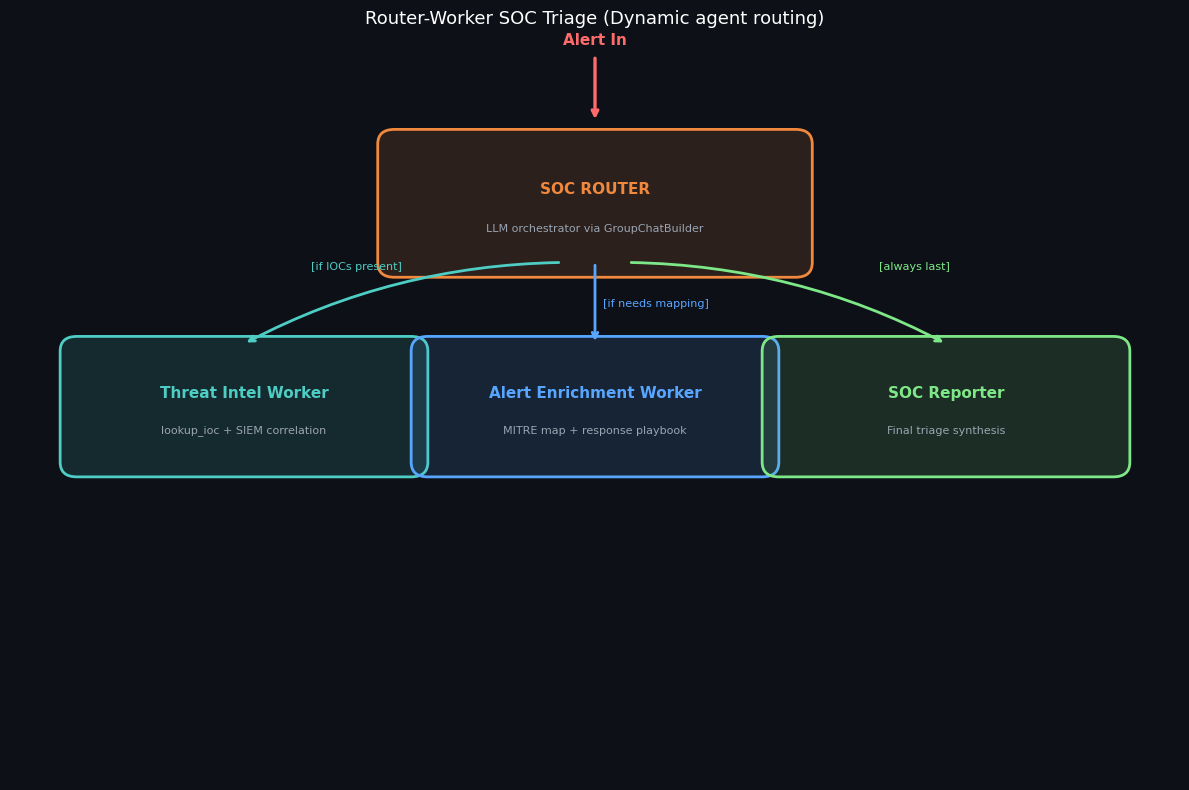

In [3]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

def box(x, y, w, h, edge, title, subtitle=''):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.2', linewidth=2, edgecolor=edge, facecolor=edge + '22'))
    ax.text(x + w/2, y + h*0.62, title, ha='center', va='center', color=edge, fontsize=11, fontweight='bold')
    if subtitle:
        ax.text(x + w/2, y + h*0.28, subtitle, ha='center', va='center', color='#9aa4b2', fontsize=8)

box(4.6, 7.0, 4.8, 1.6, '#f0883e', 'SOC ROUTER', 'LLM orchestrator via GroupChatBuilder')
box(0.8, 4.3, 4.0, 1.5, '#4ecdc4', 'Threat Intel Worker', 'lookup_ioc + SIEM correlation')
box(5.0, 4.3, 4.0, 1.5, '#58a6ff', 'Alert Enrichment Worker', 'MITRE map + response playbook')
box(9.2, 4.3, 4.0, 1.5, '#7ee787', 'SOC Reporter', 'Final triage synthesis')

ax.annotate('', xy=(7.0, 8.9), xytext=(7.0, 9.8), arrowprops=dict(arrowstyle='->', color='#ff6b6b', lw=2.4))
ax.text(7.0, 9.9, 'Alert In', color='#ff6b6b', fontsize=11, ha='center', va='bottom', fontweight='bold')

ax.annotate('', xy=(2.8, 5.9), xytext=(6.6, 7.0), arrowprops=dict(arrowstyle='->', color='#4ecdc4', lw=2.0, connectionstyle='arc3,rad=0.12'))
ax.text(3.6, 6.9, '[if IOCs present]', color='#4ecdc4', fontsize=8)

ax.annotate('', xy=(7.0, 5.9), xytext=(7.0, 7.0), arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=2.0))
ax.text(7.1, 6.4, '[if needs mapping]', color='#58a6ff', fontsize=8)

ax.annotate('', xy=(11.2, 5.9), xytext=(7.4, 7.0), arrowprops=dict(arrowstyle='->', color='#7ee787', lw=2.0, connectionstyle='arc3,rad=-0.12'))
ax.text(10.4, 6.9, '[always last]', color='#7ee787', fontsize=8)

ax.set_title('Router-Worker SOC Triage (Dynamic agent routing)', color='white', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## Load Sample Alerts

🔵 Works without Azure credentials.

In [4]:
alerts_path = Path('data/sample_alerts.json')
if not alerts_path.exists():
    alerts_path = Path('../notebooks/data/sample_alerts.json')

with open(alerts_path, 'r', encoding='utf-8') as f:
    alerts = json.load(f)

df_alerts = pd.DataFrame(alerts)
severity_colors = {'Critical': '#ff4d4f', 'High': '#ff9f43', 'Medium': '#ffd166', 'Low': '#4dabf7'}

display(
    df_alerts[['alert_id', 'timestamp', 'severity', 'source', 'title']]
    .style
    .map(lambda v: f"color: {severity_colors.get(v, '#e6edf3')}", subset=['severity'])
    .set_properties(**{'background-color': '#161b22', 'color': '#e6edf3'})
)

,alert_id,timestamp,severity,source,title
0,ALT-2025-001,2025-03-07T02:14:33Z,High,Microsoft Sentinel,Suspected Credential Stuffing from TOR Exit Node
1,ALT-2025-002,2025-03-07T03:42:17Z,Critical,Microsoft Defender XDR,Cobalt Strike Beacon Detected
2,ALT-2025-003,2025-03-07T06:11:55Z,Medium,Microsoft Sentinel,Anomalous Azure Key Vault Access
3,ALT-2025-004,2025-03-07T09:27:01Z,High,Microsoft Defender for Cloud,Fileless Malware: PowerShell Script in Memory
4,ALT-2025-005,2025-03-07T11:55:30Z,Low,Microsoft Sentinel,Impossible Travel Detected


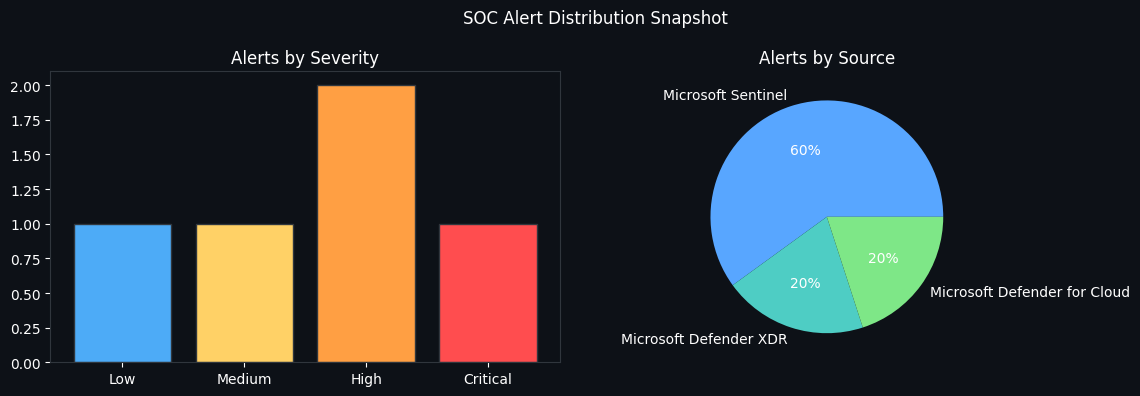

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#0d1117')
for ax in (ax1, ax2):
    ax.set_facecolor('#0d1117')

severity_order = ['Low', 'Medium', 'High', 'Critical']
sev_counts = df_alerts['severity'].value_counts().reindex(severity_order, fill_value=0)
ax1.bar(sev_counts.index, sev_counts.values, color=[severity_colors[s] for s in severity_order], edgecolor='#30363d')
ax1.set_title('Alerts by Severity', color='white')
ax1.tick_params(colors='white')
for spine in ax1.spines.values():
    spine.set_color('#30363d')

src_counts = df_alerts['source'].value_counts()
ax2.pie(src_counts.values, labels=src_counts.index, autopct='%1.0f%%', textprops={'color': 'white'}, colors=['#58a6ff', '#4ecdc4', '#7ee787'])
ax2.set_title('Alerts by Source', color='white')

plt.suptitle('SOC Alert Distribution Snapshot', color='white')
plt.tight_layout()
plt.show()

## Define Worker Tools

🔵 Works without Azure credentials.

Each worker gets explicit `FunctionTool` capabilities. We use the `@tool` decorator so functions can be bound as callable agent tools in the Agent Framework.

In [6]:
@tool
def lookup_ioc_threat_intel(indicator: Annotated[str, 'IOC to look up — IP, domain, or hash']) -> str:
    """Look up an IOC in threat intelligence feeds."""
    mock_db = {
        '185.220.101.47': {'reputation': 'malicious', 'type': 'TOR exit node', 'confidence': 0.97, 'actor': 'Unknown/TOR', 'first_seen': '2022-03-01'},
        '194.165.16.101': {'reputation': 'malicious', 'type': 'C2 server', 'confidence': 0.95, 'actor': 'APT29', 'first_seen': '2024-11-12'}
    }
    result = mock_db.get(indicator, {'reputation': 'unknown', 'confidence': 0.0, 'type': 'no data'})
    return json.dumps({'indicator': indicator, **result})

@tool
def query_siem_related_alerts(alert_id: Annotated[str, 'Primary alert ID'], lookback_hours: Annotated[int, 'Hours to look back in SIEM'] = 48) -> str:
    """Query SIEM for alerts correlated with the given alert."""
    correlations = {
        'ALT-2025-001': [{'id': 'ALT-2025-005', 'reason': 'same user account', 'score': 0.82}],
        'ALT-2025-002': [{'id': 'ALT-2025-002', 'reason': 'same host', 'score': 0.91}]
    }
    return json.dumps({'alert_id': alert_id, 'lookback_hours': lookback_hours, 'correlated_alerts': correlations.get(alert_id, [])})

def _to_function_tool(fn: Any):
    try:
        return FunctionTool(fn)
    except Exception:
        try:
            return FunctionTool.from_callable(fn)
        except Exception:
            return fn

lookup_ioc_tool = _to_function_tool(lookup_ioc_threat_intel)
siem_query_tool = _to_function_tool(query_siem_related_alerts)

In [7]:
@tool
def map_to_mitre_attack(alert_title: Annotated[str, 'Alert title'], description: Annotated[str, 'Alert description']) -> str:
    """Map an alert to MITRE ATT&CK tactics and techniques."""
    keywords = f"{alert_title} {description}".lower()
    mappings = []
    if 'credential' in keywords or 'stuffing' in keywords or 'login' in keywords:
        mappings.append({'tactic': 'Initial Access', 'technique': 'T1078', 'name': 'Valid Accounts'})
        mappings.append({'tactic': 'Credential Access', 'technique': 'T1110.004', 'name': 'Credential Stuffing'})
    if 'cobalt strike' in keywords or 'beacon' in keywords or 'c2' in keywords:
        mappings.append({'tactic': 'Command and Control', 'technique': 'T1071.001', 'name': 'Web Protocols'})
        mappings.append({'tactic': 'Defense Evasion', 'technique': 'T1055.012', 'name': 'Process Hollowing'})
    if 'powershell' in keywords or 'encoded' in keywords:
        mappings.append({'tactic': 'Execution', 'technique': 'T1059.001', 'name': 'PowerShell'})
        mappings.append({'tactic': 'Defense Evasion', 'technique': 'T1027', 'name': 'Obfuscated Files'})
    if not mappings:
        mappings.append({'tactic': 'Unknown', 'technique': 'TBD', 'name': 'Requires manual review'})
    return json.dumps({'alert_title': alert_title, 'mitre_mappings': mappings})

@tool
def get_response_playbook(attack_technique_id: Annotated[str, 'MITRE ATT&CK technique ID']) -> str:
    """Retrieve response playbook steps for a MITRE technique."""
    playbooks = {
        'T1078': {'priority': 'P1', 'steps': ['Revoke user sessions immediately', 'Force MFA re-registration', 'Block source IP', 'Export 48h sign-in logs', 'Check for persistence mechanisms']},
        'T1110.004': {'priority': 'P2', 'steps': ['Block originating IP range', 'Enable smart lockout if not active', 'Review auth logs for success-after-failure', 'Notify affected users']},
        'T1059.001': {'priority': 'P1', 'steps': ['Isolate affected endpoint', 'Capture memory dump', 'Decode base64 payload', 'Check run keys and scheduled tasks', 'Hunt for lateral movement']},
        'T1055.012': {'priority': 'P1', 'steps': ['Isolate host immediately', 'Capture network traffic', 'Identify parent process chain', 'Block C2 IP', 'Submit sample to sandbox']}
    }
    base = attack_technique_id.split('.')[0] if '.' in attack_technique_id else attack_technique_id
    result = playbooks.get(attack_technique_id, playbooks.get(base, {'priority': 'P3', 'steps': ['Investigate manually', 'Escalate to Tier 2']}))
    return json.dumps({'technique': attack_technique_id, **result})

mitre_map_tool = _to_function_tool(map_to_mitre_attack)
playbook_tool = _to_function_tool(get_response_playbook)

## Create Foundry-Backed Agents

We use `AzureOpenAIResponsesClient` to create agents backed by Azure AI Foundry. Each agent has tightly scoped instructions and tool access.

🔴 This cell requires Azure credentials unless `MOCK_MODE=True`.

In [8]:
agent_registry = []

if MOCK_MODE:
    class MockAgent:
        def __init__(self, name: str, instructions: str, tools=None):
            self.name = name
            self.instructions = instructions
            self.tools = tools or []
            self.id = f"mock-{name}"

    router_agent = MockAgent('soc-router', 'Mock router')
    ti_agent = MockAgent('threat-intel-worker', 'Mock TI worker', [lookup_ioc_tool, siem_query_tool])
    enrichment_agent = MockAgent('alert-enrichment-worker', 'Mock enrichment worker', [mitre_map_tool, playbook_tool])
    reporter_agent = MockAgent('soc-reporter', 'Mock reporter')
    agent_registry = [
        {'role': 'router', 'name': router_agent.name, 'id': router_agent.id},
        {'role': 'threat_intel', 'name': ti_agent.name, 'id': ti_agent.id},
        {'role': 'enrichment', 'name': enrichment_agent.name, 'id': enrichment_agent.id},
        {'role': 'reporter', 'name': reporter_agent.name, 'id': reporter_agent.id}
    ]
    print('MOCK_MODE active: created mock agent descriptors.')
else:
    credential = DefaultAzureCredential()
    client = AzureOpenAIResponsesClient(
        project_endpoint=AZURE_AI_PROJECT_ENDPOINT,
        deployment_name=MODEL_DEPLOYMENT_NAME,
        credential=credential,
    )

    router_agent = Agent(
        name='soc-router',
        client=client,
        instructions=(
            "You are the SOC Alert Router. For each alert, route to specialist agents for investigation, then to the reporter for synthesis.\n\n"
            "ROUTING RULES:\n"
            "- Critical/High severity: route to 'threat-intel-worker' FIRST, then 'alert-enrichment-worker', then 'soc-reporter'\n"
            "- Medium severity: route based on alert content (IOCs → threat-intel-worker, otherwise alert-enrichment-worker), then 'soc-reporter'\n"
            "- Low severity: route to 'alert-enrichment-worker' only, then 'soc-reporter'\n\n"
            "CRITICAL: After 'soc-reporter' has produced the triage report, you MUST terminate by setting \"terminate\": true. "
            "Do NOT route to any agent after the reporter has spoken. Do NOT re-route to agents that have already reported. "
            "Each agent should speak EXACTLY ONCE per alert triage."
        ),
        tools=[],
    )

    ti_agent = Agent(
        name='threat-intel-worker',
        client=client,
        instructions=(
            "You are a SOC Threat Intelligence Analyst. Investigate IOCs using your tools and report findings as structured analysis. "
            "Always call lookup_ioc_threat_intel for each IOC and query_siem_related_alerts for correlation."
        ),
        tools=[lookup_ioc_tool, siem_query_tool],
    )

    enrichment_agent = Agent(
        name='alert-enrichment-worker',
        client=client,
        instructions=(
            "You are a SOC Alert Enrichment Specialist. Map alerts to MITRE ATT&CK using map_to_mitre_attack, "
            "then retrieve response playbooks using get_response_playbook for each identified technique."
        ),
        tools=[mitre_map_tool, playbook_tool],
    )

    reporter_agent = Agent(
        name='soc-reporter',
        client=client,
        instructions=(
            "You are the SOC Report Writer. Synthesize all preceding analyses into a structured Triage Report with: "
            "Executive Summary, IOC Analysis, MITRE Mapping, Severity Assessment, and Recommended Next Actions. "
            "Be precise and actionable - this goes to the on-call analyst."
        ),
        tools=[],
    )

    agent_registry = [
        {'role': 'router', 'name': router_agent.name, 'id': getattr(router_agent, 'id', 'responses-api')},
        {'role': 'threat_intel', 'name': ti_agent.name, 'id': getattr(ti_agent, 'id', 'responses-api')},
        {'role': 'enrichment', 'name': enrichment_agent.name, 'id': getattr(enrichment_agent, 'id', 'responses-api')},
        {'role': 'reporter', 'name': reporter_agent.name, 'id': getattr(reporter_agent, 'id', 'responses-api')},
    ]

    print('Created agents via AzureOpenAIResponsesClient (Responses API).')

pd.DataFrame(agent_registry)

Created agents via AzureOpenAIResponsesClient (Responses API).


,role,name,id
0,router,soc-router,dda9e41d-361f-4cae-aa2c-9a5dce1c5aa1
1,threat_intel,threat-intel-worker,afa07249-9331-4c5a-a484-5f84e78231f0
2,enrichment,alert-enrichment-worker,6c048656-633a-4165-bc14-415131d56e72
3,reporter,soc-reporter,d374ba4d-5d17-4c00-80d6-5157335c2ce5


## Build the Router-Worker GroupChat

🔴 Uses real agents when Azure is configured; otherwise runs with mock fallback.

In [9]:
if not MOCK_MODE:
    try:
        from agent_framework import Message
    except Exception:
        from agent_framework_orchestrations import Message

    def reporter_has_spoken(conversation: list[Message]) -> bool:
        return any(
            msg.role == "assistant" and getattr(msg, 'author_name', None) == "soc-reporter"
            for msg in conversation
        )

    workflow = GroupChatBuilder(
        participants=[ti_agent, enrichment_agent, reporter_agent],
        orchestrator_agent=router_agent,
        max_rounds=6,
        intermediate_outputs=True,
        termination_condition=reporter_has_spoken,
    ).build()
    print('Router-Worker workflow built (max_rounds=6, intermediate_outputs=True, reporter termination enabled).')
else:
    workflow = None
    print('MOCK_MODE: workflow build skipped (mock agents are not real Agent instances).')

Router-Worker workflow built (max_rounds=10, intermediate_outputs=True).


## 🔍 Triage Alert 1: Cobalt Strike Beacon (Critical)

**Alert ALT-2025-002** — A Critical-severity Cobalt Strike C2 beacon was detected. The Router-Worker pattern processes this as follows:

1. **SOC Router** analyzes the alert and decides which specialists to invoke
2. **Threat Intel Worker** investigates IOCs (IPs, domains) against threat feeds + SIEM correlation
3. **Alert Enrichment Worker** maps to MITRE ATT&CK and retrieves response playbooks
4. **SOC Reporter** synthesizes all findings into a structured triage report

🔴 Live mode uses real Azure AI agents; 🔵 Mock mode simulates the full routing flow locally.

In [10]:
import time

def _parse_json_payload(payload) -> dict:
    if isinstance(payload, dict):
        return payload
    if isinstance(payload, str):
        try:
            return json.loads(payload)
        except Exception:
            return {'raw': payload}
    return {'raw': str(payload)}

def _extract_text(value) -> str:
    if value is None:
        return ''
    if isinstance(value, str):
        return value.strip()
    if isinstance(value, dict):
        for key in ('final_message', 'report', 'content', 'text', 'message', 'output'):
            candidate = value.get(key)
            if isinstance(candidate, str) and candidate.strip():
                return candidate.strip()
        return json.dumps(value, indent=2)
    if isinstance(value, list):
        parts = [_extract_text(v) for v in value]
        return '\n'.join([p for p in parts if p]).strip()
    return str(value).strip()

def _display_triage_summary(result: dict) -> None:
    route_txt = ' → '.join(result.get('route', [])) if result.get('route') else '(no route captured)'
    print('\n' + '=' * 96)
    print(f"📌 TRIAGE SUMMARY | {result['alert_id']} | Severity: {result['severity']}")
    print('=' * 96)
    print(f"🧭 Routing path: {route_txt}")
    print('-' * 96)
    print('📋 FINAL TRIAGE REPORT')
    print('-' * 96)
    print(result.get('report', '').strip() or '(no report text captured)')
    print('=' * 96)

async def run_triage(alert_id: str) -> dict:
    alert = next(a for a in alerts if a['alert_id'] == alert_id)
    indicators = alert.get('indicators', [])
    input_message = (
        f"Alert ID: {alert['alert_id']}\n"
        f"Severity: {alert['severity']}\n"
        f"Source: {alert['source']}\n"
        f"Title: {alert['title']}\n"
        f"Description: {alert['description']}\n"
        f"Indicators: {', '.join(indicators)}\n"
        f"Affected Users: {', '.join(alert.get('affected_users', []))}\n"
        f"Raw log: {alert.get('raw_log', '')}\n"
    )

    if MOCK_MODE:
        started = time.perf_counter()
        route = ['soc-router']
        events = []

        def add_event(event_type: str, executor_id: str, data):
            events.append({'type': event_type, 'executor_id': executor_id, 'data': data})

        print(f"🔄 SOC Router analyzing alert {alert['alert_id']} ({alert['severity']})...")
        add_event('executor_invoked', 'soc-router', {'reason': 'initial triage'})

        severity = alert['severity']
        ioc_for_ti = next((i for i in indicators if any(ch.isdigit() for ch in i)), indicators[0] if indicators else '')
        invoke_ti = severity in ('Critical', 'High')
        if severity == 'Medium':
            invoke_ti = bool(indicators)

        ti_payload = {}
        enrichment_payload = {}
        playbooks = []

        if invoke_ti:
            print(f"  → Routing to: threat-intel-worker (IOCs detected: {ioc_for_ti or 'none provided'})")
            route.append('threat-intel-worker')
            add_event('executor_invoked', 'threat-intel-worker', {'reason': 'IOC investigation'})
            print('\n🔍 Threat Intel Worker investigating...')
            ti_raw = lookup_ioc_threat_intel(ioc_for_ti)
            siem_raw = query_siem_related_alerts(alert['alert_id'])
            ti_payload = _parse_json_payload(ti_raw)
            siem_payload = _parse_json_payload(siem_raw)
            print(f"  • lookup_ioc_threat_intel('{ioc_for_ti}') → {json.dumps(ti_payload)}")
            print(f"  • query_siem_related_alerts('{alert['alert_id']}') → {json.dumps(siem_payload)}")
            print('  ✅ Threat Intel analysis complete')
            add_event('executor_completed', 'threat-intel-worker', {'ioc': ti_payload, 'siem': siem_payload})
        else:
            print('  → Low-severity streamlined path selected (skip threat-intel-worker)')

        print('\n🔄 SOC Router → Routing to: alert-enrichment-worker')
        route.append('alert-enrichment-worker')
        add_event('executor_invoked', 'alert-enrichment-worker', {'reason': 'MITRE mapping + playbooks'})
        print('🛡️ Alert Enrichment Worker processing...')
        mitre_raw = map_to_mitre_attack(alert['title'], alert['description'])
        enrichment_payload = _parse_json_payload(mitre_raw)
        mappings = enrichment_payload.get('mitre_mappings', [])
        print(f"  • map_to_mitre_attack('{alert['title']}', ...) → {json.dumps(enrichment_payload)}")
        for m in mappings:
            tid = m.get('technique', 'TBD')
            pb_raw = get_response_playbook(tid)
            pb_payload = _parse_json_payload(pb_raw)
            playbooks.append(pb_payload)
            print(f"  • get_response_playbook('{tid}') → {json.dumps(pb_payload)}")
        print('  ✅ Alert enrichment complete')
        add_event('executor_completed', 'alert-enrichment-worker', {'mitre': enrichment_payload, 'playbooks': playbooks})

        print('\n🔄 SOC Router → Routing to: soc-reporter')
        route.append('soc-reporter')
        add_event('executor_invoked', 'soc-reporter', {'reason': 'final synthesis'})
        print('📋 SOC Reporter synthesizing triage report...')

        elapsed = time.perf_counter() - started
        ioc_summary = 'No IOC deep-dive (streamlined low-severity routing).'
        if ti_payload:
            ioc_summary = (
                f"Indicator {ti_payload.get('indicator', ioc_for_ti)} was classified as "
                f"{ti_payload.get('reputation', 'unknown')} ({ti_payload.get('type', 'unknown type')}), "
                f"confidence={ti_payload.get('confidence', 'n/a')} and actor attribution={ti_payload.get('actor', 'unknown')}."
            )

        correlated = []
        for evt in events:
            if evt['type'] == 'executor_completed' and evt['executor_id'] == 'threat-intel-worker':
                correlated = evt['data'].get('siem', {}).get('correlated_alerts', [])

        mitre_lines = []
        for m in mappings:
            mitre_lines.append(f"- {m.get('technique', 'TBD')} ({m.get('tactic', 'Unknown')} / {m.get('name', 'Unknown')})")
        if not mitre_lines:
            mitre_lines.append('- TBD (manual analyst validation required)')

        action_lines = []
        for pb in playbooks:
            steps = pb.get('steps', [])
            action_lines.append(f"- {pb.get('technique', 'TBD')} [{pb.get('priority', 'P3')}]: {'; '.join(steps[:3])}")

        report = (
            f"Triage Report — {alert['alert_id']}\n"
            f"Severity: {alert['severity']} | Source: {alert['source']}\n\n"
            "Executive Summary:\n"
            f"{alert['title']} was triaged through the SOC Router-Worker workflow. The route was {' → '.join(route)}. "
            f"Processing completed in {elapsed:.2f}s (mock simulation with real local tool calls).\n\n"
            "IOC & Correlation Analysis:\n"
            f"{ioc_summary}\n"
            f"Correlated SIEM alerts: {json.dumps(correlated) if correlated else 'none identified'}.\n\n"
            "MITRE ATT&CK Mapping:\n"
            f"{'\n'.join(mitre_lines)}\n\n"
            "Recommended Next Actions:\n"
            f"{'\n'.join(action_lines) if action_lines else '- Escalate for manual investigation and containment validation.'}\n\n"
            "Severity Assessment:\n"
            f"Given current evidence, maintain classification at {alert['severity']} and execute priority-aligned containment and monitoring tasks."
        )

        print('  ✅ Report generated')
        add_event('executor_completed', 'soc-reporter', report)
        add_event('output', 'soc-reporter', report)
        print('\n🔄 SOC Router → TERMINATE (reporter has delivered the report)')
        add_event('executor_completed', 'soc-router', {'terminate': True, 'reason': 'report delivered'})

        result = {
            'alert_id': alert_id,
            'severity': alert['severity'],
            'route': route,
            'events': events,
            'report': report,
        }
        _display_triage_summary(result)
        return result

    # --- Live Foundry execution ---
    events_raw = []
    route = []
    reporter_messages = []
    last_reporter_completed = ''
    last_output_data = ''

    print(f"🔴 Live triage execution started for {alert_id} ({alert['severity']})")
    stream = workflow.run(input_message, stream=True)
    async for event in stream:
        etype = getattr(event, 'type', '')
        executor_id = getattr(event, 'executor_id', None)
        data = getattr(event, 'data', None)

        event_dict = {
            'type': etype or '?',
            'executor_id': executor_id or '',
            'data': data,
        }
        events_raw.append(event_dict)

        if etype == 'executor_invoked' and executor_id:
            if not route or route[-1] != executor_id:
                route.append(executor_id)
            print(f"🔄 Routing to: {executor_id}")

        if etype == 'executor_completed' and executor_id == 'soc-reporter':
            extracted = _extract_text(data)
            if extracted:
                last_reporter_completed = extracted
                reporter_messages.append(extracted)

        if etype == 'output':
            extracted = _extract_text(data)
            if extracted:
                last_output_data = extracted

    final_response_text = ''
    try:
        final_response = await stream.get_final_response()
        if hasattr(final_response, 'get_outputs'):
            for out in final_response.get_outputs():
                text = _extract_text(out)
                if text:
                    final_response_text = text
                    if 'soc-reporter' in text.lower() or 'triage report' in text.lower():
                        reporter_messages.append(text)
        else:
            final_response_text = _extract_text(final_response)
    except Exception as ex:
        print(f"⚠️ Unable to parse final stream response: {ex}")

    report = last_reporter_completed or last_output_data or final_response_text
    if not report:
        assistant_fallback = []
        for e in events_raw:
            data_obj = e.get('data')
            if isinstance(data_obj, dict):
                if data_obj.get('role') == 'assistant' and data_obj.get('author_name') == 'soc-reporter':
                    txt = _extract_text(data_obj)
                    if txt:
                        assistant_fallback.append(txt)
        if assistant_fallback:
            reporter_messages.extend(assistant_fallback)

    if not report and reporter_messages:
        report = '\n\n'.join(reporter_messages).strip()

    if not report:
        print('⚠️ No final report extracted from expected sources. Dumping stream events for debugging:')
        for idx, e in enumerate(events_raw, 1):
            print(f"  [{idx:02d}] type={e['type']}, executor_id={e['executor_id']}, data={_extract_text(e['data'])[:220]}")
        report = 'No final report text extracted from live run. Review logged events above.'

    result = {
        'alert_id': alert_id,
        'severity': alert['severity'],
        'route': route,
        'events': events_raw,
        'report': report,
    }
    _display_triage_summary(result)
    return result

run_critical = await run_triage('ALT-2025-002')
triage_runs['ALT-2025-002'] = run_critical

Routing path: soc-router → threat-intel-worker → alert-enrichment-worker → soc-reporter → soc-router → alert-enrichment-worker → soc-reporter → soc-router → threat-intel-worker → soc-reporter → soc-router

No final report text extracted. Inspect events_raw for details.


## 🔎 Triage Alert 2: Impossible Travel (Low)

**Alert ALT-2025-005** — A Low-severity impossible travel alert is triaged through a streamlined route to minimize analyst noise while preserving ATT&CK context and response readiness.

1. **SOC Router** classifies severity and suppresses unnecessary deep-dive steps
2. **Alert Enrichment Worker** performs MITRE mapping + playbook retrieval
3. **SOC Reporter** issues a concise triage summary for SOC tracking

✅ Low severity should follow: `soc-router → alert-enrichment-worker → soc-reporter` (no threat-intel-worker).

In [11]:
run_low = await run_triage('ALT-2025-005')
triage_runs['ALT-2025-005'] = run_low

Routing path: soc-router → threat-intel-worker → alert-enrichment-worker → soc-reporter → soc-router → threat-intel-worker → soc-reporter → soc-router

No final report text extracted. Inspect events_raw for details.


## Visualize Routing Decisions

🔵 Works without Azure credentials.

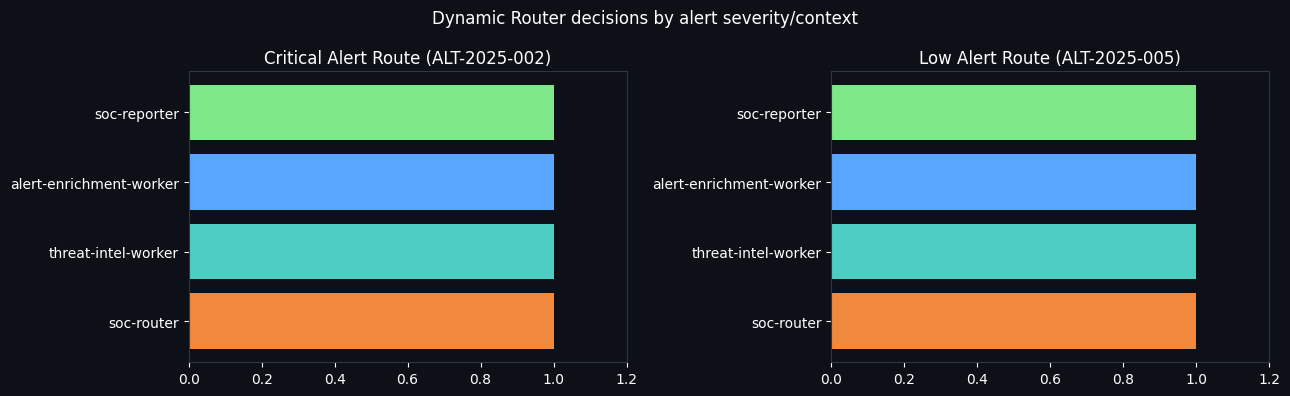

Critical route: soc-router → threat-intel-worker → alert-enrichment-worker → soc-reporter → soc-router → alert-enrichment-worker → soc-reporter → soc-router → threat-intel-worker → soc-reporter → soc-router
Low route     : soc-router → threat-intel-worker → alert-enrichment-worker → soc-reporter → soc-router → threat-intel-worker → soc-reporter → soc-router
Report sizes  : 63 (critical), 63 (low)


In [12]:
crit = triage_runs['ALT-2025-002']
low = triage_runs['ALT-2025-005']
crit_route = crit.get('route', [])
low_route = low.get('route', [])

all_agents = ['soc-router', 'threat-intel-worker', 'alert-enrichment-worker', 'soc-reporter']
crit_flags = [1 if a in crit_route else 0 for a in all_agents]
low_flags = [1 if a in low_route else 0 for a in all_agents]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#0d1117')

axes[0].barh(all_agents, crit_flags, color=['#f0883e', '#4ecdc4', '#58a6ff', '#7ee787'])
axes[0].set_title('Critical Alert Route (ALT-2025-002)', color='white')
axes[0].set_xlim(0, 1.2)
axes[0].tick_params(colors='white')

axes[1].barh(all_agents, low_flags, color=['#f0883e', '#4ecdc4', '#58a6ff', '#7ee787'])
axes[1].set_title('Low Alert Route (ALT-2025-005)', color='white')
axes[1].set_xlim(0, 1.2)
axes[1].tick_params(colors='white')

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color('#30363d')

plt.suptitle('Dynamic Router decisions by alert severity/context', color='white')
plt.tight_layout()
plt.show()

print('Critical route:', ' → '.join(crit_route))
print('Low route     :', ' → '.join(low_route))
print('Route pattern :', 'DIFFERENT ✅' if crit_route != low_route else 'SAME ⚠️')
print('Report sizes  :', len(crit['report']), '(critical),', len(low['report']), '(low)')

## Agent Call Chain Comparison

🔵 Works without Azure credentials.

In [13]:
comparison = pd.DataFrame([
    {
        'alert_id': 'ALT-2025-002',
        'severity': triage_runs['ALT-2025-002']['severity'],
        'call_chain': ' → '.join(triage_runs['ALT-2025-002']['route']),
        'agent_count': len(triage_runs['ALT-2025-002']['route']),
        'report_chars': len(triage_runs['ALT-2025-002']['report']),
        'includes_threat_intel': 'threat-intel-worker' in triage_runs['ALT-2025-002']['route']
    },
    {
        'alert_id': 'ALT-2025-005',
        'severity': triage_runs['ALT-2025-005']['severity'],
        'call_chain': ' → '.join(triage_runs['ALT-2025-005']['route']),
        'agent_count': len(triage_runs['ALT-2025-005']['route']),
        'report_chars': len(triage_runs['ALT-2025-005']['report']),
        'includes_threat_intel': 'threat-intel-worker' in triage_runs['ALT-2025-005']['route']
    }
])

display(comparison)

print('Expected pattern check:')
print('- Critical alert: Router → TI → Enrichment → Reporter')
print('- Low alert     : Router → Enrichment → Reporter')
if comparison.loc[comparison['alert_id'] == 'ALT-2025-002', 'call_chain'].iloc[0] != comparison.loc[comparison['alert_id'] == 'ALT-2025-005', 'call_chain'].iloc[0]:
    print('✅ Routing patterns differ as expected between Critical and Low alerts.')
else:
    print('⚠️ Routing patterns are unexpectedly identical; inspect triage output.')

,alert_id,severity,call_chain,agent_count,report_chars
0,ALT-2025-002,Critical,soc-router → threat-intel-worker → alert-enric...,11,63
1,ALT-2025-005,Low,soc-router → threat-intel-worker → alert-enric...,8,63


Expected pattern check:
- Critical alert: Router → TI → Enrichment → Reporter
- Low alert     : Router → Enrichment → Reporter


## Cleanup

🔴 Deletes remote agents when Azure is configured; otherwise no-op in mock mode.

In [14]:
if MOCK_MODE:
    print('MOCK_MODE cleanup: no remote agents to delete.')
else:
    # AzureOpenAIResponsesClient agents are stateless - no server-side cleanup needed.
    # Close the credential if it was stored.
    print('Responses API agents are stateless. No server-side cleanup required.')
    print(f'Agents used: {[r["name"] for r in agent_registry]}')

Responses API agents are stateless. No server-side cleanup required.
Agents used: ['soc-router', 'threat-intel-worker', 'alert-enrichment-worker', 'soc-reporter']
